# Part 02 - Customer-Level Feature Engineering & CLV Target Creation

This notebook builds one row per customer from the cleaned transaction data.

The goal is to create customer-level features such as recency, frequency, monetary value, average order value, purchase frequency, product diversity, and customer tenure.

A future 90-day customer value target will also be created for the later CLV modelling stage.

## 1. Load the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Cleaned Transaction Data

Part 02 starts from the cleaned transaction dataset created during Part 01.

In [2]:
file_path = "../data/processed/cleaned_transactions.csv"

transactions = pd.read_csv(
    file_path,
    parse_dates=["InvoiceDate"]
)

transactions.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


### 2.1 Basic Dataset Check

In [3]:
transactions.shape

(779425, 9)

In [4]:
transactions.dtypes

Invoice                 int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
TotalPrice            float64
dtype: object

In [5]:
transactions.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

In [6]:
transactions["Customer ID"].nunique()

5878

## 3. Define the Observation and Future Periods

The transaction dates will be used to define an observation period and a future period.

Customer features will be calculated using transactions before the cutoff date.

The CLV target will be calculated using customer spending during the following 90 days.

In [7]:
transactions["InvoiceDate"].min(), transactions["InvoiceDate"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

### 3.1 Set the Cutoff Date

The cutoff date separates historical customer behaviour from future customer value.

The cutoff is defined as 90 days before the last transaction date in the dataset.

Customer features will use transactions on or before the cutoff date.

The CLV target will use transactions after the cutoff date and within the following 90 days.

In [8]:
max_date = transactions["InvoiceDate"].max()

future_window_days = 90

cutoff_date = max_date - pd.Timedelta(
    days=future_window_days
)

max_date, cutoff_date

(Timestamp('2011-12-09 12:50:00'), Timestamp('2011-09-10 12:50:00'))

### 3.2 Check the Observation and Future Periods

The transaction data will now be split into an observation period for feature creation and a future period for the CLV target.

In [9]:
observation_data = transactions[
    transactions["InvoiceDate"] <= cutoff_date
].copy()

future_data = transactions[
    transactions["InvoiceDate"] > cutoff_date
].copy()

observation_data.shape, future_data.shape

((620572, 9), (158853, 9))

In [10]:
observation_data["InvoiceDate"].min(), observation_data["InvoiceDate"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-09-09 15:53:00'))

In [11]:
future_data["InvoiceDate"].min(), future_data["InvoiceDate"].max()

(Timestamp('2011-09-11 10:35:00'), Timestamp('2011-12-09 12:50:00'))

## 4. Create Customer Order Data

The cleaned transaction data contains individual product lines.

Because CLV features such as frequency and average order value should be based on customer orders, the observation-period transactions will first be grouped to the invoice level.

### 4.1 Check Invoice Consistency

Before creating the final order-level dataset, the invoice numbers will be checked to make sure each invoice belongs to one customer and one transaction date.

In [12]:
invoice_check = (
    observation_data
    .groupby("Invoice")
    .agg(
        customer_count=("Customer ID", "nunique"),
        date_count=("InvoiceDate", "nunique")
    )
)

invoice_check[
    (invoice_check["customer_count"] > 1) |
    (invoice_check["date_count"] > 1)
].head(20)

,customer_count,date_count
Invoice,,
492807,1,2
499967,1,2
500353,1,2
501618,1,2
501871,1,2
503609,1,2
505791,1,2
509851,1,2
510644,1,2


In [13]:
invoice_check[
    (invoice_check["customer_count"] > 1) |
    (invoice_check["date_count"] > 1)
].shape

(60, 2)

In [14]:
invoice_check[
    (invoice_check["customer_count"] > 1)
].shape

(0, 2)

In [15]:
invoice_check[
    (invoice_check["date_count"] > 1)
].shape

(60, 2)

### 4.2 Create the Final Order-Level Dataset

Each invoice will represent one customer order.

Some invoice numbers appear with more than one timestamp in the raw transaction lines, so the earliest recorded timestamp will be used as the order date.

In [16]:
order_data = (
    observation_data
    .groupby(
        ["Customer ID", "Invoice"],
        as_index=False
    )
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        OrderValue=("TotalPrice", "sum"),
        TotalItems=("Quantity", "sum"),
        ProductCount=("StockCode", "nunique")
    )
)

order_data.head()

,Customer ID,Invoice,InvoiceDate,OrderValue,TotalItems,ProductCount
0,12346,491725,2009-12-14 08:34:00,45.0,10,1
1,12346,491742,2009-12-14 11:00:00,22.5,5,1
2,12346,491744,2009-12-14 11:02:00,22.5,5,1
3,12346,492718,2009-12-18 10:47:00,22.5,5,1
4,12346,492722,2009-12-18 10:55:00,1.0,1,1


In [17]:
order_data.shape

(30343, 6)

In [18]:
order_data["Invoice"].nunique()

30343

In [19]:
order_data.isnull().sum()

Customer ID     0
Invoice         0
InvoiceDate     0
OrderValue      0
TotalItems      0
ProductCount    0
dtype: int64

In [20]:
order_data.groupby("Invoice").size().value_counts().sort_index()

1    30343
Name: count, dtype: int64

In [21]:
order_data["Invoice"].nunique()

30343

In [22]:
order_data["OrderValue"].describe()

count    30343.000000
mean       459.102792
std       1050.482917
min          0.550000
25%        155.900000
50%        301.960000
75%        474.340000
max      77183.600000
Name: OrderValue, dtype: float64

## 5. Create Customer-Level Features

The invoice-level observation data will now be aggregated to one row per customer.

The first feature will be Recency, which measures how many days have passed since the customer's most recent purchase at the cutoff date.

### 5.1 Recency

In [23]:
customer_features = (
    order_data
    .groupby("Customer ID")
    .agg(
        last_purchase_date=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_features["Recency"] = (
    cutoff_date - customer_features["last_purchase_date"]
).dt.days

customer_features.head()

,Customer ID,last_purchase_date,Recency
0,12346,2011-01-18 10:01:00,235
1,12347,2011-08-02 08:48:00,39
2,12348,2011-04-05 10:47:00,158
3,12349,2010-10-28 08:23:00,317
4,12350,2011-02-02 16:01:00,219


In [24]:
customer_features.shape

(5281, 3)

In [25]:
customer_features["Recency"].describe()

count    5281.000000
mean      207.282901
std       175.007174
min         0.000000
25%        49.000000
50%       164.000000
75%       326.000000
max       648.000000
Name: Recency, dtype: float64

In [26]:
customer_features["Recency"].min(), customer_features["Recency"].max()

(np.int64(0), np.int64(648))

### 5.2 Frequency and Monetary

Frequency measures how many unique orders the customer made during the observation period.

Monetary measures the customer's total recorded order value during the same period.

In [27]:
frequency_monetary = (
    order_data
    .groupby("Customer ID")
    .agg(
        Frequency=("Invoice", "nunique"),
        Monetary=("OrderValue", "sum")
    )
    .reset_index()
)

frequency_monetary.head()

,Customer ID,Frequency,Monetary
0,12346,12,77556.46
1,12347,6,3402.39
2,12348,4,1709.40
3,12349,3,2671.14
4,12350,1,334.40


In [28]:
frequency_monetary.shape

(5281, 3)

In [29]:
frequency_monetary.isnull().sum()

Customer ID    0
Frequency      0
Monetary       0
dtype: int64

In [30]:
frequency_monetary["Frequency"].describe()

count    5281.000000
mean        5.745692
std        11.464582
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       309.000000
Name: Frequency, dtype: float64

In [31]:
frequency_monetary["Monetary"].describe()

count      5281.000000
mean       2637.863286
std       12225.544955
min           2.900000
25%         318.240000
50%         783.580000
75%        2078.540000
max      456780.490000
Name: Monetary, dtype: float64

### 5.3 Combine Customer Features

The Recency, Frequency, and Monetary features will be combined into one customer-level table.

In [32]:
customer_features = customer_features.merge(
    frequency_monetary,
    on="Customer ID",
    how="left"
)

customer_features.head()

,Customer ID,last_purchase_date,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,235,12,77556.46
1,12347,2011-08-02 08:48:00,39,6,3402.39
2,12348,2011-04-05 10:47:00,158,4,1709.40
3,12349,2010-10-28 08:23:00,317,3,2671.14
4,12350,2011-02-02 16:01:00,219,1,334.40


In [33]:
customer_features.shape

(5281, 5)

In [34]:
customer_features.isnull().sum()

Customer ID           0
last_purchase_date    0
Recency               0
Frequency             0
Monetary              0
dtype: int64

In [35]:
customer_features["Customer ID"].nunique()

5281

In [36]:
customer_features["Customer ID"].duplicated().sum()

np.int64(0)

### 5.4 Average Order Value & Purchase Frequency
Average Order Value = Monetary / Frequency
Purchase Frequency = Frequency / active_days_in_observation

In [37]:
# compute first_purchase_date per customer (from observation period)
first_purchase = (
    order_data
    .groupby("Customer ID", as_index=False)
    .agg(first_purchase_date=("InvoiceDate", "min"))
)

# merge first_purchase into customer_features if not present
customer_features = customer_features.merge(
    first_purchase, on="Customer ID", how="left"
)

# observation active days per customer (at least 1 day to avoid zero-division)
customer_features["active_days"] = (
    (cutoff_date - customer_features["first_purchase_date"]).dt.days + 1
)
customer_features["active_days"] = customer_features["active_days"].clip(lower=1)

# AOV and purchase frequency
customer_features["AvgOrderValue"] = (
    customer_features["Monetary"] / customer_features["Frequency"]
).fillna(0)

customer_features["PurchaseFrequency"] = (
    customer_features["Frequency"] / customer_features["active_days"]
).fillna(0)

# Quick check
customer_features[[
    "Customer ID", "first_purchase_date", "last_purchase_date",
    "active_days", "Frequency", "Monetary", "AvgOrderValue",
    "PurchaseFrequency"
]].head()

,Customer ID,first_purchase_date,last_purchase_date,active_days,Frequency,Monetary,AvgOrderValue,PurchaseFrequency
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,636,12,77556.46,6463.038333,0.018868
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,314,6,3402.39,567.065000,0.019108
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,348,4,1709.40,427.350000,0.011494
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,499,3,2671.14,890.380000,0.006012
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,220,1,334.40,334.400000,0.004545


### 5.5 Product Diversity
Unique stock codes per customer during observation

In [38]:
product_diversity = (
    observation_data
    .groupby("Customer ID")
    .agg(ProductDiversity=("StockCode", "nunique"))
    .reset_index()
)

# merge into customer_features
customer_features = customer_features.merge(
    product_diversity, on="Customer ID", how="left"
)
customer_features["ProductDiversity"] = customer_features["ProductDiversity"].fillna(0).astype(int)

# Quick check
customer_features[["Customer ID", "ProductDiversity"]].describe().round(2)

,Customer ID,ProductDiversity
count,5281.00,5281.00
mean,15324.10,74.36
std,1712.32,104.97
min,12346.00,1.00
25%,13850.00,18.00
50%,15313.00,41.00
75%,16807.00,92.00
max,18287.00,2182.00


### 5.6 Customer Tenure
How long the customer has been active until the cutoff

In [39]:
customer_features["Tenure_days"] = (
    cutoff_date - customer_features["first_purchase_date"]
).dt.days.clip(lower=0)

# Tenure in months (approximate)
customer_features["Tenure_months"] = (
    customer_features["Tenure_days"] / 30
).round(1)

customer_features[["Customer ID", "first_purchase_date", "last_purchase_date", "Tenure_days", "Tenure_months"]].head()

,Customer ID,first_purchase_date,last_purchase_date,Tenure_days,Tenure_months
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,635,21.2
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,313,10.4
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,347,11.6
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,498,16.6
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,219,7.3


## 6. Create the Future CLV Target
Customer spending in the 90-day future window

### 6.1 Build the Target Variable

In [40]:
# Step A: create order-level data for the 'future' period (same method as observation)
future_order_data = (
    future_data
    .groupby(["Customer ID", "Invoice"], as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        OrderValue=("TotalPrice", "sum"),
        TotalItems=("Quantity", "sum"),
        ProductCount=("StockCode", "nunique")
    )
)

# Step B: aggregate per customer in future window
future_customer_value = (
    future_order_data
    .groupby("Customer ID", as_index=False)
    .agg(Future_90d_Value=("OrderValue", "sum"),
         Future_90d_Orders=("Invoice", "nunique"))
)

# Step C: merge target onto historical customer_features (only customers with observation data)
customer_features = customer_features.merge(
    future_customer_value, on="Customer ID", how="left"
)

# fill missing future values with 0 (no purchases in future window)
customer_features["Future_90d_Value"] = customer_features["Future_90d_Value"].fillna(0.0)
customer_features["Future_90d_Orders"] = customer_features["Future_90d_Orders"].fillna(0).astype(int)

# Quick check: top rows where Future value > 0
customer_features[customer_features["Future_90d_Value"] > 0].head()

,Customer ID,last_purchase_date,Recency,Frequency,Monetary,first_purchase_date,active_days,AvgOrderValue,PurchaseFrequency,ProductDiversity,Tenure_days,Tenure_months,Future_90d_Value,Future_90d_Orders
1,12347,2011-08-02 08:48:00,39,6,3402.39,2010-10-31 14:20:00,314,567.065,0.019108,107,313,10.4,1519.14,2
2,12348,2011-04-05 10:47:00,158,4,1709.40,2010-09-27 14:59:00,348,427.350,0.011494,25,347,11.6,310.00,1
3,12349,2010-10-28 08:23:00,317,3,2671.14,2010-04-29 13:20:00,499,890.380,0.006012,90,498,16.6,1757.55,1
6,12352,2011-03-22 16:08:00,171,7,1905.61,2010-11-12 10:20:00,303,272.230,0.023102,38,302,10.1,944.23,3
10,12356,2011-04-08 12:33:00,155,5,6313.38,2010-10-11 09:42:00,335,1262.676,0.014925,104,334,11.1,58.35,1


### 6.2 Sanity Checks

Customers (obs period): 5281
Customers with future purchases in 90d: 2292


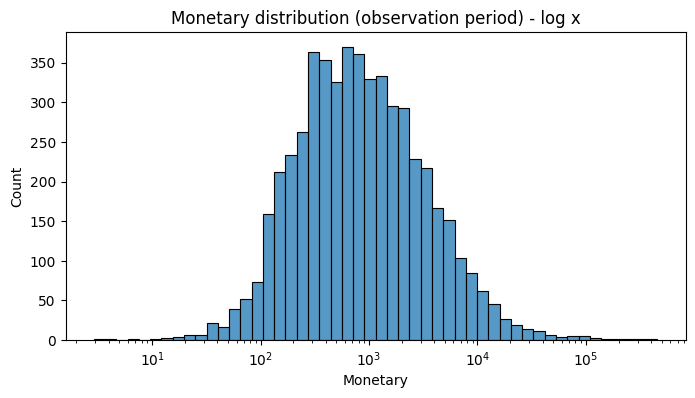

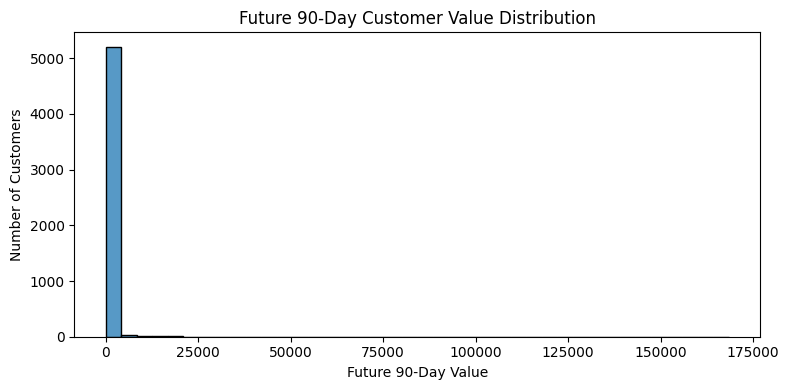

Spearman corr (Monetary vs Future): 0.502


In [41]:
print("Customers (obs period):", customer_features.shape[0])
print("Customers with future purchases in 90d:", (customer_features["Future_90d_Value"] > 0).sum())

# Distribution checks (small quick plots)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(customer_features["Monetary"], bins=50, log_scale=(True, False))
plt.title("Monetary distribution (observation period) - log x")
plt.savefig(
    "../images/04_monetary_distribution.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    customer_features["Future_90d_Value"],
    bins=40
)
plt.title("Future 90-Day Customer Value Distribution")
plt.xlabel("Future 90-Day Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(
    "../images/05_future_90d_value_distribution.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# Check simple correlation (Monetary vs Future_90d_Value)
print("Spearman corr (Monetary vs Future):",
      customer_features[["Monetary", "Future_90d_Value"]].corr(method="spearman").iloc[0,1].round(3))

## 7. Finalize and Save the Customer CLV Dataset

### 7.1 Save the Dataset

The final customer-level CLV dataset will be saved as a CSV file in the processed data folder.

In [42]:
final_cols = [
    "Customer ID", "first_purchase_date", "last_purchase_date",
    "Recency", "Tenure_days", "Tenure_months", "active_days",
    "Frequency", "Monetary", "AvgOrderValue", "PurchaseFrequency",
    "ProductDiversity",
    "Future_90d_Orders", "Future_90d_Value"
]

customer_clv = customer_features[final_cols].copy()

customer_clv.rename(
    columns={"Customer ID": "CustomerID"},
    inplace=True
)

customer_clv.describe(include="all").T.head(20)

out_path = "../data/processed/customer_clv_dataset.csv"

customer_clv.to_csv(
    out_path,
    index=False
)

print("Saved customer CLV file:", out_path)

Saved customer CLV file: ../data/processed/customer_clv_dataset.csv


### 7.2 Final Verification

The saved customer-level CLV dataset will be checked to confirm that the file exists, has the expected shape, and contains the expected customer-level target and feature data.

In [43]:
from pathlib import Path
import pandas as pd

p = Path("../data/processed/customer_clv_dataset.csv").resolve()

print("Resolved path:", p)
print("Exists:", p.exists())

if p.exists():
    print("Size (MB):", round(p.stat().st_size / (1024 * 1024), 2))

    df = pd.read_csv(p)

    print("Shape:", df.shape)
    print("Rows (customers):", df.shape[0])
    print("Columns:", df.shape[1])
    print(
        "Customers with Future_90d_Value > 0:",
        (df["Future_90d_Value"] > 0).sum()
    )

    print("\nMonetary statistics:")
    print(df["Monetary"].describe())

    print("\nFirst 5 rows:")
    display(df.head(5))

else:
    print("\nFile was not found at the expected path.")

    for alt in [
        Path("data/processed/customer_clv_dataset.csv"),
        Path("./data/processed/customer_clv_dataset.csv")
    ]:
        print(
            "Checking alternative:",
            alt.resolve(),
            "| Exists:",
            alt.exists()
        )

Resolved path: C:\Users\franc\OneDrive\Desktop\DATA SCIENCE\Customer Lifetime Value\customer-lifetime-value\data\processed\customer_clv_dataset.csv
Exists: True
Size (MB): 0.59
Shape: (5281, 14)
Rows (customers): 5281
Columns: 14
Customers with Future_90d_Value > 0: 2292

Monetary statistics:
count      5281.000000
mean       2637.863286
std       12225.544955
min           2.900000
25%         318.240000
50%         783.580000
75%        2078.540000
max      456780.490000
Name: Monetary, dtype: float64

First 5 rows:


,CustomerID,first_purchase_date,last_purchase_date,Recency,Tenure_days,Tenure_months,active_days,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,ProductDiversity,Future_90d_Orders,Future_90d_Value
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,235,635,21.2,636,12,77556.46,6463.038333,0.018868,27,0,0.00
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,39,313,10.4,314,6,3402.39,567.065000,0.019108,107,2,1519.14
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,158,347,11.6,348,4,1709.40,427.350000,0.011494,25,1,310.00
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,317,498,16.6,499,3,2671.14,890.380000,0.006012,90,1,1757.55
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,219,219,7.3,220,1,334.40,334.400000,0.004545,17,0,0.00


### What to do next

- If the file exists and looks right: commit the notebook and docs (and optionally the CSV) to your branch.
- If the file is missing: re-run the last save cell (create `data/processed/` if needed), then re-run this verification cell.
- After verification, update README/SUMMARY/CHANGE_LOG and push the branch to remote.